# Modelado y XAI — Alta contaminación por PM2.5 (Rol B)

**Proyecto:** *Dos Limas, un mismo cielo* — Contaminación del aire en Lima Metropolitana.

Este notebook documenta el **Panel 2 (predictivo)**. Reutiliza el pipeline de Rol A
(`preprocessing.cargar_y_limpiar`) y el módulo `models.py`; no reimplementa nada, para
que el notebook y el dashboard produzcan **exactamente los mismos resultados**.

**Decisiones (justificadas en `models.py`):**

- Etiqueta `y = (pm_25 > ECA_PM25)`, con `ECA_PM25 = 50` µg/m³ como constante única.
- Features = los 5 contaminantes restantes (se excluye `pm_25` para evitar fuga).
- Solo etiqueta **real** (`pm_25_imputado == False`).
- Sin escalado (RF/XGBoost son invariantes a escala).
- Desbalance ~92/8 → se compara `class_weight`, `scale_pos_weight` y SMOTE.
- `SEED = 96` importado de Rol A (reproducibilidad de todo el equipo).

In [1]:
import sys, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import pandas as pd
import core.models as M
from core.preprocessing import cargar_y_limpiar

print("SEED:", M.SEED, "| ECA_PM25:", M.ECA_PM25, "| FEATURES:", M.FEATURES)

SEED: 96 | ECA_PM25: 50.0 | FEATURES: ['pm_10', 'so2', 'no2', 'o3', 'co']


## 1. Carga del dataset limpio (Rol A)

In [2]:
df = cargar_y_limpiar(str(M.RUTA_DATOS))
print("shape:", df.shape)
df[["estacion", "fecha_hora", *M.CONTAMINANTES, "pm_25_imputado"]].head()

shape: (514680, 18)


,estacion,fecha_hora,pm_10,pm_25,so2,no2,o3,co,pm_25_imputado
0,ATE,2014-10-01 00:00:00,116.26,43.2,21.4,42.20,5.00,1422.30,False
1,ATE,2014-10-01 01:00:00,125.31,45.5,22.1,40.65,5.00,1358.00,False
2,ATE,2014-10-01 02:00:00,124.78,54.5,22.8,38.40,5.05,1288.70,False
3,ATE,2014-10-01 03:00:00,144.21,66.8,23.5,38.20,5.30,1228.45,False
4,ATE,2014-10-01 04:00:00,159.18,76.8,21.4,38.25,5.10,1167.65,False


## 2. Construcción de la etiqueta binaria

`construir_dataset_modelado` filtra a PM2.5 medido, deriva `y` y arma `X` con las 5
features. Las aserciones internas garantizan que `pm_25` no se cuele como feature.

In [3]:
X, y = M.construir_dataset_modelado(df)
print("X:", X.shape, "| features:", list(X.columns))
print(f"positivos (alta): {y.mean()*100:.1f}%  ->  desbalance que motiva SMOTE/class_weight")
y.value_counts()

X: (320209, 5) | features: ['pm_10', 'so2', 'no2', 'o3', 'co']
positivos (alta): 7.9%  ->  desbalance que motiva SMOTE/class_weight


alta_contaminacion
0    294800
1     25409
Name: count, dtype: int64

## 3. Partición train/test (estratificada, 70/30)

In [4]:
X_train, X_test, y_train, y_test = M.dividir(X, y)
print("train:", len(X_train), "| test:", len(X_test))
print("balance en test:", round(y_test.mean()*100, 2), "% positivos")

train: 224146 | test: 96063
balance en test: 7.94 % positivos


## 4. Entrenamiento: RF vs XGBoost vs RF+SMOTE

Tres estrategias frente al desbalance: `class_weight='balanced'` (RF),
`scale_pos_weight` (XGBoost, mecanismo nativo) y **SMOTE** (sobremuestreo sintético,
solo en train). *Nota: entrenar los tres puede tardar algunos minutos.*

In [5]:
salida = M.entrenar_y_evaluar_todo(df)
salida["tabla"]

,f1_alta,recall_alta,precision_alta,roc_auc,accuracy
modelo,,,,,
rf_classweight,0.5031,0.4847,0.5229,0.9067,0.9240
rf_smote,0.4737,0.6638,0.3682,0.8980,0.8830
xgb_scaleposw,0.4057,0.8111,0.2705,0.8998,0.8115


## 5. Comparación y elección del mejor modelo

Se ordena por **F1 de la clase 'alta'** (la minoritaria y la relevante). El costo de un
**falso negativo** (no avisar una hora contaminada) es mayor que el de un falso positivo,
así que priorizamos recall/F1 de esa clase sobre el accuracy global.

In [6]:
mejor = salida["mejor"]
print("Mejor modelo:", mejor)
for clave, r in salida["resultados"].items():
    print(f"{clave:16s} F1_alta={r['clase_1_alta']['f1']:.3f} "
          f"recall_alta={r['clase_1_alta']['recall']:.3f} roc_auc={r['roc_auc']:.3f}")

Mejor modelo: rf_classweight
rf_classweight   F1_alta=0.503 recall_alta=0.485 roc_auc=0.907
xgb_scaleposw    F1_alta=0.406 recall_alta=0.811 roc_auc=0.900
rf_smote         F1_alta=0.474 recall_alta=0.664 roc_auc=0.898


## 6. Matriz de confusión

TP/TN/FP/FN del mejor modelo. La lectura clave: ¿cuántas horas realmente contaminadas
se nos escapan (FN) vs. cuántas falsas alarmas (FP)?

{'tn': 85068, 'fp': 3372, 'fn': 3928, 'tp': 3695}


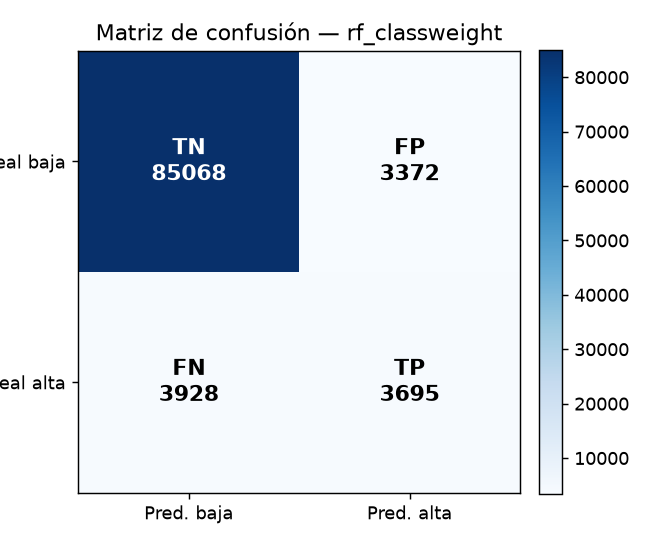

In [7]:
from pathlib import Path
from IPython.display import Image
r_mejor = salida["resultados"][mejor]
print(r_mejor["matriz_confusion"])
from application.graficos import figura_matriz_confusion
figura_matriz_confusion(r_mejor, Path("../models/confusion_matrix.png"),
                        titulo=f"Matriz de confusión — {mejor}")
Image("../models/confusion_matrix.png")

## 7. Umbral de decisión (modificación en vivo)

Bajar el umbral de 0.50 a 0.30 reetiqueta **sin reentrenar**: sube el recall de 'alta'
a costa de precisión. Es la respuesta a la pregunta típica *'recall bajo, ¿qué harías?'*.

In [8]:
modelo = salida["modelos"][mejor]
for u in (0.50, 0.30):
    r = M.evaluar(modelo, salida["X_test"], salida["y_test"], umbral=u)
    print(f"umbral={u:.2f} -> recall_alta={r['clase_1_alta']['recall']:.3f} "
          f"precision_alta={r['clase_1_alta']['precision']:.3f} "
          f"f1_alta={r['clase_1_alta']['f1']:.3f}")

umbral=0.50 -> recall_alta=0.485 precision_alta=0.523 f1_alta=0.503


umbral=0.30 -> recall_alta=0.709 precision_alta=0.369 f1_alta=0.486


## 8. Interpretabilidad (SHAP)

`summary_plot` (global): qué contaminantes empujan la predicción hacia 'alta'.
`force_plot` (local): descomposición de una instancia concreta. Con esto respondemos
*'¿por qué el modelo predijo X para este caso?'* y discutimos correlación vs. causalidad
(p. ej. si `pm_10` domina, es esperable porque comparte fuentes de combustión con PM2.5).

1. Importando SHAP...


2. Calculando SHAP values...


3. Generando summary_plot...
4. Guardando summary...


5. Generando force_plot...
6. Guardando force...


7. SHAP terminado.


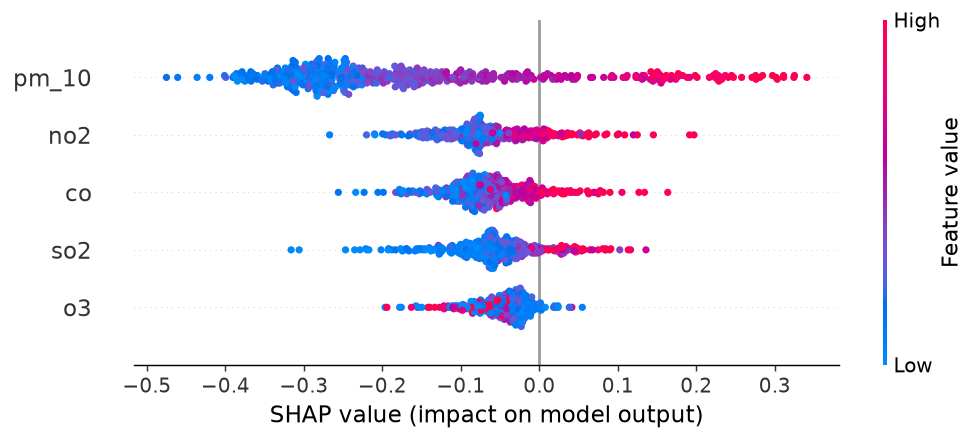

In [9]:
from application.graficos import explicar_shap
rutas = explicar_shap(salida["modelos"][mejor], salida["X_test"],
                     Path("../models"), prefijo=mejor)
Image(rutas["summary"])

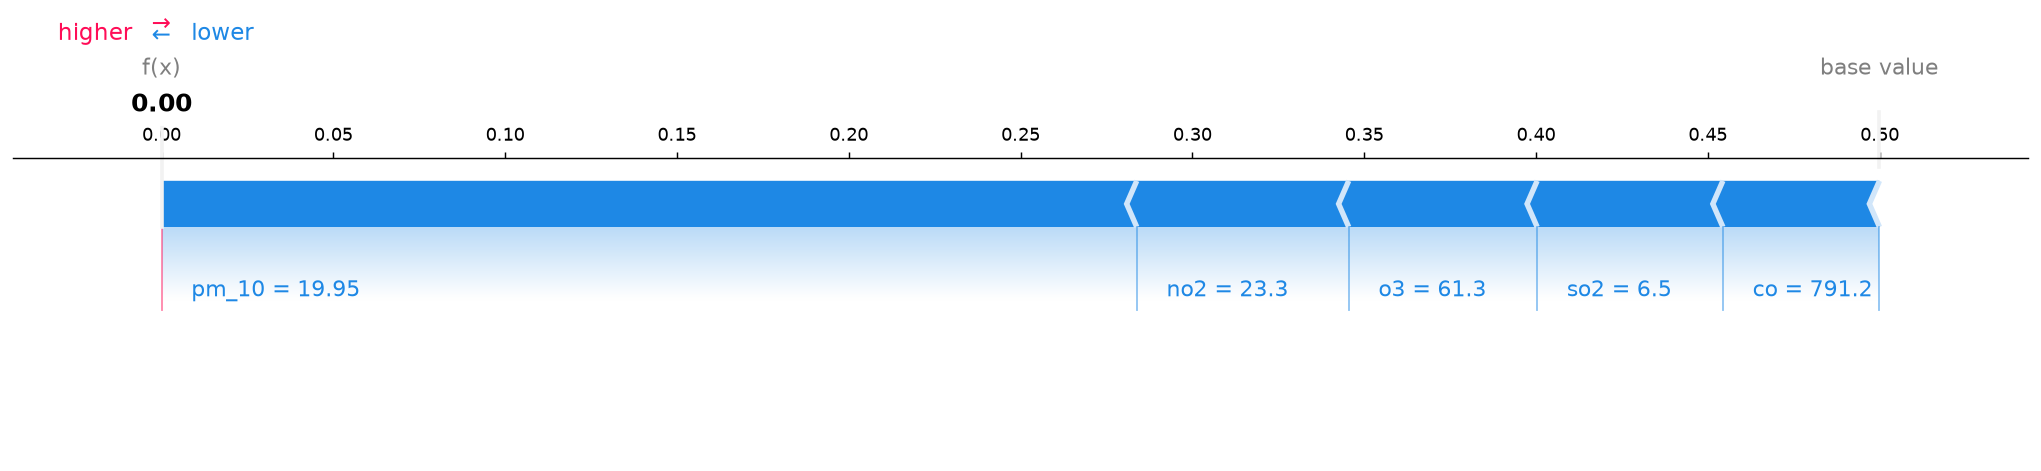

In [10]:
Image(rutas["force"])

## 9. Persistencia de artefactos

Se guardan modelos y métricas para el dashboard y el Reporte PDF. `metrics.json` es la
**fuente de verdad** de las cifras que se muestran en el Panel 2.

In [11]:
import json
M.DIR_MODELOS.mkdir(exist_ok=True)
M.guardar_modelo(salida["modelos"]["rf_classweight"], M.DIR_MODELOS/"rf.pkl")
M.guardar_modelo(salida["modelos"]["xgb_scaleposw"], M.DIR_MODELOS/"xgb.pkl")
M.guardar_modelo(salida["modelos"]["rf_smote"], M.DIR_MODELOS/"rf_smote.pkl")
metrics = M._construir_metrics_json(salida)
(M.DIR_MODELOS/"metrics.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2))
print("Artefactos escritos en", M.DIR_MODELOS)
metrics

Artefactos escritos en C:\2026\W MINERIA\air-contamination\models


{'generado_utc': '2026-07-15T01:54:06+00:00',
 'seed': 96,
 'umbral_eca_pm25': 50.0,
 'umbral_decision': 0.5,
 'test_size': 0.3,
 'solo_real': True,
 'features': ['pm_10', 'so2', 'no2', 'o3', 'co'],
 'objetivo': 'pm_25',
 'n_train': 224146,
 'n_test': 96063,
 'balance_positivos_pct': 7.935,
 'mejor_modelo': 'rf_classweight',
 'modelos': {'rf_classweight': {'nombre': 'rf_classweight',
   'umbral': 0.5,
   'accuracy': 0.9240082029501473,
   'roc_auc': 0.9066624255026253,
   'matriz_confusion': {'tn': 85068, 'fp': 3372, 'fn': 3928, 'tp': 3695},
   'clase_0_baja': {'precision': 0.955863184862241,
    'recall': 0.9618724559023066,
    'f1': 0.9588584052841588},
   'clase_1_alta': {'precision': 0.5228526956275648,
    'recall': 0.48471730289912107,
    'f1': 0.5030633083730429}},
  'xgb_scaleposw': {'nombre': 'xgb_scaleposw',
   'umbral': 0.5,
   'accuracy': 0.8114570646346668,
   'roc_auc': 0.8997924895575073,
   'matriz_confusion': {'tn': 71768, 'fp': 16672, 'fn': 1440, 'tp': 6183},
   'cl

---
**Reproducir todo de una sola vez** (equivalente a este notebook):

```bash
uv run python src/models.py
```